In [1]:
# frist we will read the data set 
import pandas as pd
import numpy as np


df=pd.read_csv('../Dataset/fake_and_real_news.csv')

In [2]:
df

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real
...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake
9896,Trump consults Republican senators on Fed chie...,Real
9897,Trump lawyers say judge lacks jurisdiction for...,Real
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake


In [3]:
t1=df['Text'][2:3]

print(t1.to_string())

2    Trump proposes U.S. tax overhaul, stirs concer...


In [4]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

df['label']=encoder.fit_transform(df['label'])

In [5]:
df.label.value_counts()

label
0    5000
1    4900
Name: count, dtype: int64

In [ ]:
# text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
import re
l1=WordNetLemmatizer()
corpus=[]

# stop_words=stopwords.words("english")
for i in range(len(df['Text'])):
    words=re.sub('[^a-zA-z]',' ',df['Text'][i].lower())
    words=words.split()
    #remove the stop wors and stemming
    word=[l1.lemmatize(j) for j in words]
    corpus.append(" ".join(word))
    

In [8]:
corpus

['top trump surrog brutal stab him in the back he s pathet video it s look as though republican presidenti candid donald trump is lose support even from within hi own rank you know thing are get bad when even your top surrog start turn against you which is exactli what just happen on fox news when newt gingrich call trump pathet gingrich know that trump need to keep hi focu on hillari clinton if he even remot want to have a chanc at defeat her howev trump ha hurt feel becaus mani republican don t support hi sexual assault against women have turn against him includ hous speaker paul ryan r wi so that ha made trump lash out as hi own parti gingrich said on fox news look first of all let me just say about trump who i admir and i ve tri to help as much as i can there s a big trump and a littl trump the littl trump is frankli pathet i mean he s mad over not get a phone call trump s refer to the fact that paul ryan didn t call to congratul him after the debat probabl becaus he didn t win des

In [9]:
#tokinozation

from tensorflow.keras.preprocessing.text import Tokenizer

t1=Tokenizer(num_words=20000,oov_token="<OOV>")

t1.fit_on_texts(corpus)


In [10]:
len(t1.index_word)

40641

In [11]:
seq=t1.texts_to_sequences(corpus)

In [12]:
len(seq)

9900

In [13]:
max([len(i) for i in seq])

5254

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

seq_pad=pad_sequences(seq,maxlen=800)

In [15]:
seq_pad

array([[   0,    0,    0, ..., 2501,  189,   64],
       [   0,    0,    0, ...,    5,  239,   97],
       [ 210,  523,   10, ..., 1798,   69,  235],
       ...,
       [   0,    0,    0, ...,  204,    4, 2439],
       [   0,    0,    0, ...,   64,  189,   64],
       [  18, 5848,  228, ...,   28, 3160,  213]],
      shape=(9900, 800), dtype=int32)

In [16]:
#build an lstm model
from tensorflow.keras.layers import Dense,Embedding,Flatten,LSTM,Dropout,Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
model=Sequential()
model.add(Embedding(input_dim=20000,input_length=800,output_dim=120))
model.add(Bidirectional(LSTM(128,return_sequences=True,dropout=0.5)))
model.add(LSTM(64,dropout=0.5))
model.add(Dense(1,activation='sigmoid'))

model.build((None,800))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 800, 120)       │     2,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 800, 256)       │       254,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,737,217 (10.44 MB)

 Trainable params: 2,737,217 (10.44 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#trin test split

from sklearn.model_selection import train_test_split

x_train,x_test,y_test,y_train=train_test_split(seq_pad,df['label'],test_size=0.2)

In [25]:
x_train.shape,x_test.shape

((7920, 800), (1980, 800))

In [26]:
y_test.shape,y_train.shape

((7920,), (1980,))

In [27]:
Early_Stopping=EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [28]:
#model trainning

history=model.fit(x_train,y_test,epochs=10,validation_data=(x_test,y_train),verbose=1,callbacks=[Early_Stopping])

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9833 - loss: 0.0683 - val_accuracy: 0.9949 - val_loss: 0.0199
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9961 - loss: 0.0153 - val_accuracy: 0.9965 - val_loss: 0.0193
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9965 - val_loss: 0.0213
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9970 - val_loss: 0.0216


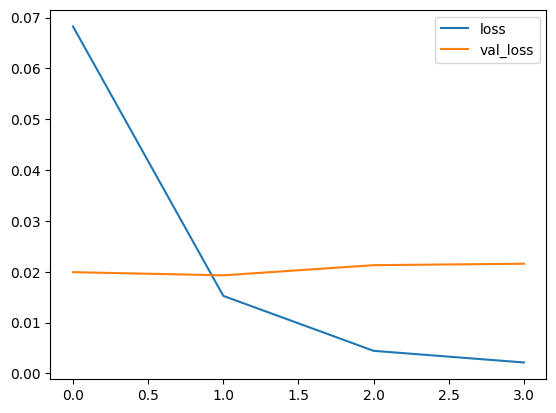

In [29]:
# loss visuazation

import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()


In [34]:
model.save('m2.h5')

In [30]:
test_predicted=model.predict(x_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step


In [31]:
test_predicted

array([[0.9994045 ],
       [0.99948794],
       [0.999538  ],
       ...,
       [0.99949616],
       [0.00101952],
       [0.9996526 ]], shape=(1980, 1), dtype=float32)

In [32]:
y_pred = (test_predicted >= 0.5).astype(int)


F1_score:0.9963369963369964
Precision:0.9937369519832986
Recall:0.9989506820566632
accuracy_score:0.9964646464646465
confusion_matrix: Axes(0.125,0.11;0.62x0.77)


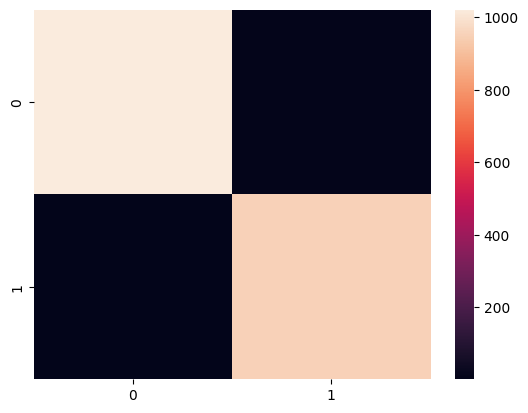

In [33]:
#preformance measure of the model

from sklearn.metrics import precision_score,recall_score,confusion_matrix,f1_score,accuracy_score
import seaborn as sns

print(f"F1_score:{f1_score(y_train,y_pred)}")
print(f"Precision:{precision_score(y_train,y_pred)}")
print(f"Recall:{recall_score(y_train,y_pred)}")
print(f"accuracy_score:{accuracy_score(y_train,y_pred)}")

print("confusion_matrix:",sns.heatmap(confusion_matrix(y_train,y_pred)))

In [ ]:
import pickle as pkl
with open('tokenizer.pkl','wb') as file:
    pkl.dump(t1,file)